# 06 - Confronto finale BB84 vs E91

Questo notebook raccoglie un confronto sintetico tra BB84 ed E91 nei principali scenari del progetto.

Gli scenari considerati sono: caso ideale, attacco intercept-resend di Eve, sorgente classica per E91 e rumori rappresentativi. Le metriche usate sono QBER, sifted key rate, accettazione rispetto alla soglia e parametro CHSH per E91.

L'obiettivo è produrre risultati finali compatti per la relazione e per la discussione orale.

## Setup

In [5]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_path = project_root / "src"
if not src_path.exists():
    raise FileNotFoundError("Cartella src non trovata. Avvia il notebook dalla root del progetto o da notebooks/.")

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from bb84 import run_bb84_protocol, run_bb84_protocol_with_eve
from e91 import (
    run_e91_protocol,
    run_e91_protocol_with_eve,
    run_e91_protocol_with_classical_source,
    run_chsh_experiment,
    run_chsh_experiment_with_eve,
    run_chsh_experiment_with_classical_source,
)
from bb84_noise import (
    run_bb84_protocol_with_bit_flip_noise,
    run_bb84_protocol_with_amplitude_damping,
    run_bb84_protocol_with_jc_amplitude_damping,
)
from e91_noise import (
    run_e91_protocol_with_bit_flip_noise,
    run_e91_protocol_with_amplitude_damping,
    run_e91_protocol_with_jc_amplitude_damping,
    run_chsh_experiment_with_bit_flip_noise,
    run_chsh_experiment_with_amplitude_damping,
    run_chsh_experiment_with_jc_amplitude_damping,
)
from noise_models import compute_jc_damping_probability_from_distance
from qkd_core import sift_keys, compute_qber
from metrics import (
    compute_sifted_key_length,
    compute_sifted_key_rate,
    decide_qber_acceptance,
    QBER_THRESHOLD_BB84,
    CHSH_CLASSICAL_LIMIT,
    CHSH_TSIRELSON_BOUND,
)

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Setup completato.")

Setup completato.


## Parametri

In [6]:
N_ROUNDS = 1000
SHOTS_CHSH = 2000
SEED = 42

QBER_THRESHOLD = QBER_THRESHOLD_BB84
CHANNEL_MODE = "two_arm"

REPRESENTATIVE_NOISE_PROBABILITY = 0.10
REPRESENTATIVE_DAMPING_PROBABILITY = 0.10
REPRESENTATIVE_DISTANCE_KM = 50

print("Numero di round:", N_ROUNDS)
print("Shot CHSH:", SHOTS_CHSH)
print("Seed:", SEED)
print("Soglia QBER:", QBER_THRESHOLD)
print("Modo canale E91:", CHANNEL_MODE)

Numero di round: 1000
Shot CHSH: 2000
Seed: 42
Soglia QBER: 0.11
Modo canale E91: two_arm


## Funzioni locali di supporto

In [7]:
def compute_notebook_qkd_metrics(results):
    # Supporto locale per evitare ripetizioni nella costruzione delle tabelle.
    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)
    sifted_key_length = compute_sifted_key_length(alice_key)
    sifted_key_rate = compute_sifted_key_rate(alice_key, len(results))
    accepted = decide_qber_acceptance(qber, QBER_THRESHOLD)

    return {
        "sifted_key_length": sifted_key_length,
        "sifted_key_rate": sifted_key_rate,
        "qber": qber,
        "accepted": accepted,
    }


def annotate_bars(ax, bars):
    # Aggiunge il valore numerico sopra ogni barra.
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
        )

## Scenari QKD principali

In [8]:
main_rows = []

bb84_ideal_results = run_bb84_protocol(N_ROUNDS, seed=SEED)
bb84_ideal_metrics = compute_notebook_qkd_metrics(bb84_ideal_results)
main_rows.append({
    "protocol": "BB84",
    "scenario": "BB84 ideal",
    "n_rounds": N_ROUNDS,
    "sifted_key_length": bb84_ideal_metrics["sifted_key_length"],
    "sifted_key_rate": bb84_ideal_metrics["sifted_key_rate"],
    "qber": bb84_ideal_metrics["qber"],
    "qber_threshold": QBER_THRESHOLD,
    "accepted": bb84_ideal_metrics["accepted"],
    "seed": SEED,
})

bb84_eve_results = run_bb84_protocol_with_eve(N_ROUNDS, intercept_probability=1.0, seed=SEED)
bb84_eve_metrics = compute_notebook_qkd_metrics(bb84_eve_results)
main_rows.append({
    "protocol": "BB84",
    "scenario": "BB84 Eve intercept-resend",
    "n_rounds": N_ROUNDS,
    "sifted_key_length": bb84_eve_metrics["sifted_key_length"],
    "sifted_key_rate": bb84_eve_metrics["sifted_key_rate"],
    "qber": bb84_eve_metrics["qber"],
    "qber_threshold": QBER_THRESHOLD,
    "accepted": bb84_eve_metrics["accepted"],
    "seed": SEED,
})

e91_ideal_results = run_e91_protocol(N_ROUNDS, seed=SEED)
e91_ideal_metrics = compute_notebook_qkd_metrics(e91_ideal_results)
main_rows.append({
    "protocol": "E91",
    "scenario": "E91 ideal",
    "n_rounds": N_ROUNDS,
    "sifted_key_length": e91_ideal_metrics["sifted_key_length"],
    "sifted_key_rate": e91_ideal_metrics["sifted_key_rate"],
    "qber": e91_ideal_metrics["qber"],
    "qber_threshold": QBER_THRESHOLD,
    "accepted": e91_ideal_metrics["accepted"],
    "seed": SEED,
})

e91_eve_results = run_e91_protocol_with_eve(N_ROUNDS, intercept_probability=1.0, seed=SEED)
e91_eve_metrics = compute_notebook_qkd_metrics(e91_eve_results)
main_rows.append({
    "protocol": "E91",
    "scenario": "E91 Eve intercept-resend",
    "n_rounds": N_ROUNDS,
    "sifted_key_length": e91_eve_metrics["sifted_key_length"],
    "sifted_key_rate": e91_eve_metrics["sifted_key_rate"],
    "qber": e91_eve_metrics["qber"],
    "qber_threshold": QBER_THRESHOLD,
    "accepted": e91_eve_metrics["accepted"],
    "seed": SEED,
})

e91_classical_results = run_e91_protocol_with_classical_source(N_ROUNDS, seed=SEED)
e91_classical_metrics = compute_notebook_qkd_metrics(e91_classical_results)
main_rows.append({
    "protocol": "E91",
    "scenario": "E91 classical source",
    "n_rounds": N_ROUNDS,
    "sifted_key_length": e91_classical_metrics["sifted_key_length"],
    "sifted_key_rate": e91_classical_metrics["sifted_key_rate"],
    "qber": e91_classical_metrics["qber"],
    "qber_threshold": QBER_THRESHOLD,
    "accepted": e91_classical_metrics["accepted"],
    "seed": SEED,
})

final_qkd_df = pd.DataFrame(main_rows)
final_qkd_path = tables_dir / "final_qkd_comparison.csv"
final_qkd_df.to_csv(final_qkd_path, index=False)

print(f"Tabella salvata in: {final_qkd_path}")
final_qkd_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\final_qkd_comparison.csv


,protocol,scenario,n_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,seed
0,BB84,BB84 ideal,1000,509,0.509,0.000000,0.11,True,42
1,BB84,BB84 Eve intercept-resend,1000,509,0.509,0.235756,0.11,False,42
2,E91,E91 ideal,1000,489,0.489,0.000000,0.11,True,42
3,E91,E91 Eve intercept-resend,1000,489,0.489,0.257669,0.11,False,42
4,E91,E91 classical source,1000,489,0.489,0.267894,0.11,False,42


## CHSH principale per E91

In [9]:
chsh_rows = []

chsh_ideal = run_chsh_experiment(shots=SHOTS_CHSH, seed=SEED)
chsh_rows.append({
    "scenario": "E91 ideal",
    "shots": SHOTS_CHSH,
    "S": chsh_ideal["S"],
    "abs_S": abs(chsh_ideal["S"]),
    "violates_chsh": abs(chsh_ideal["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": chsh_ideal["chsh_gap"],
    "chsh_strength": chsh_ideal["chsh_strength"],
})

chsh_eve = run_chsh_experiment_with_eve(intercept_probability=1.0, shots=SHOTS_CHSH, seed=SEED)
chsh_rows.append({
    "scenario": "E91 Eve intercept-resend",
    "shots": SHOTS_CHSH,
    "S": chsh_eve["S"],
    "abs_S": abs(chsh_eve["S"]),
    "violates_chsh": abs(chsh_eve["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": chsh_eve["chsh_gap"],
    "chsh_strength": chsh_eve["chsh_strength"],
})

chsh_classical = run_chsh_experiment_with_classical_source(shots=SHOTS_CHSH, seed=SEED)
chsh_rows.append({
    "scenario": "E91 classical source",
    "shots": SHOTS_CHSH,
    "S": chsh_classical["S"],
    "abs_S": abs(chsh_classical["S"]),
    "violates_chsh": abs(chsh_classical["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": chsh_classical["chsh_gap"],
    "chsh_strength": chsh_classical["chsh_strength"],
})

final_chsh_df = pd.DataFrame(chsh_rows)
final_chsh_path = tables_dir / "final_e91_chsh_comparison.csv"
final_chsh_df.to_csv(final_chsh_path, index=False)

print(f"Tabella salvata in: {final_chsh_path}")
final_chsh_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\final_e91_chsh_comparison.csv


,scenario,shots,S,abs_S,violates_chsh,chsh_gap,chsh_strength
0,E91 ideal,2000,2.817,2.817,True,0.817,0.986206
1,E91 Eve intercept-resend,2000,1.444,1.444,False,-0.556,-0.671151
2,E91 classical source,2000,1.443,1.443,False,-0.557,-0.672358


## Scenari rumore rappresentativi

In [10]:
noise_rows = []

bb84_bit_flip_results = run_bb84_protocol_with_bit_flip_noise(
    N_ROUNDS,
    noise_probability=REPRESENTATIVE_NOISE_PROBABILITY,
    seed=SEED,
)
bb84_bit_flip_metrics = compute_notebook_qkd_metrics(bb84_bit_flip_results)
noise_rows.append({
    "protocol": "BB84",
    "scenario": "BB84 bit-flip p=0.10",
    "noise_model": "bit_flip",
    "parameter": "p = 0.10",
    "qber": bb84_bit_flip_metrics["qber"],
    "sifted_key_rate": bb84_bit_flip_metrics["sifted_key_rate"],
    "accepted": bb84_bit_flip_metrics["accepted"],
    "abs_S": None,
    "violates_chsh": None,
    "chsh_gap": None,
    "chsh_strength": None,
})

bb84_damping_results = run_bb84_protocol_with_amplitude_damping(
    N_ROUNDS,
    damping_probability=REPRESENTATIVE_DAMPING_PROBABILITY,
    seed=SEED,
)
bb84_damping_metrics = compute_notebook_qkd_metrics(bb84_damping_results)
noise_rows.append({
    "protocol": "BB84",
    "scenario": "BB84 amplitude damping gamma=0.10",
    "noise_model": "amplitude_damping",
    "parameter": "gamma = 0.10",
    "qber": bb84_damping_metrics["qber"],
    "sifted_key_rate": bb84_damping_metrics["sifted_key_rate"],
    "accepted": bb84_damping_metrics["accepted"],
    "abs_S": None,
    "violates_chsh": None,
    "chsh_gap": None,
    "chsh_strength": None,
})

bb84_jc_results = run_bb84_protocol_with_jc_amplitude_damping(
    N_ROUNDS,
    distance_km=REPRESENTATIVE_DISTANCE_KM,
    seed=SEED,
)
bb84_jc_metrics = compute_notebook_qkd_metrics(bb84_jc_results)
bb84_jc_probability = compute_jc_damping_probability_from_distance(REPRESENTATIVE_DISTANCE_KM)
noise_rows.append({
    "protocol": "BB84",
    "scenario": "BB84 JC distance=50 km",
    "noise_model": "jc_amplitude_damping",
    "parameter": "distance = 50 km",
    "damping_probability": bb84_jc_probability,
    "qber": bb84_jc_metrics["qber"],
    "sifted_key_rate": bb84_jc_metrics["sifted_key_rate"],
    "accepted": bb84_jc_metrics["accepted"],
    "abs_S": None,
    "violates_chsh": None,
    "chsh_gap": None,
    "chsh_strength": None,
})

e91_bit_flip_results = run_e91_protocol_with_bit_flip_noise(
    N_ROUNDS,
    noise_probability=REPRESENTATIVE_NOISE_PROBABILITY,
    channel_mode=CHANNEL_MODE,
    seed=SEED,
)
e91_bit_flip_metrics = compute_notebook_qkd_metrics(e91_bit_flip_results)
e91_bit_flip_chsh = run_chsh_experiment_with_bit_flip_noise(
    noise_probability=REPRESENTATIVE_NOISE_PROBABILITY,
    channel_mode=CHANNEL_MODE,
    shots=SHOTS_CHSH,
    seed=SEED,
)
noise_rows.append({
    "protocol": "E91",
    "scenario": "E91 bit-flip p=0.10",
    "noise_model": "bit_flip",
    "parameter": "p = 0.10",
    "qber": e91_bit_flip_metrics["qber"],
    "sifted_key_rate": e91_bit_flip_metrics["sifted_key_rate"],
    "accepted": e91_bit_flip_metrics["accepted"],
    "abs_S": abs(e91_bit_flip_chsh["S"]),
    "violates_chsh": abs(e91_bit_flip_chsh["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": e91_bit_flip_chsh["chsh_gap"],
    "chsh_strength": e91_bit_flip_chsh["chsh_strength"],
})

e91_damping_results = run_e91_protocol_with_amplitude_damping(
    N_ROUNDS,
    damping_probability=REPRESENTATIVE_DAMPING_PROBABILITY,
    channel_mode=CHANNEL_MODE,
    seed=SEED,
)
e91_damping_metrics = compute_notebook_qkd_metrics(e91_damping_results)
e91_damping_chsh = run_chsh_experiment_with_amplitude_damping(
    damping_probability=REPRESENTATIVE_DAMPING_PROBABILITY,
    channel_mode=CHANNEL_MODE,
    shots=SHOTS_CHSH,
    seed=SEED,
)
noise_rows.append({
    "protocol": "E91",
    "scenario": "E91 amplitude damping gamma=0.10",
    "noise_model": "amplitude_damping",
    "parameter": "gamma = 0.10",
    "qber": e91_damping_metrics["qber"],
    "sifted_key_rate": e91_damping_metrics["sifted_key_rate"],
    "accepted": e91_damping_metrics["accepted"],
    "abs_S": abs(e91_damping_chsh["S"]),
    "violates_chsh": abs(e91_damping_chsh["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": e91_damping_chsh["chsh_gap"],
    "chsh_strength": e91_damping_chsh["chsh_strength"],
})

e91_jc_results = run_e91_protocol_with_jc_amplitude_damping(
    N_ROUNDS,
    distance_km=REPRESENTATIVE_DISTANCE_KM,
    channel_mode=CHANNEL_MODE,
    seed=SEED,
)
e91_jc_metrics = compute_notebook_qkd_metrics(e91_jc_results)
e91_jc_chsh = run_chsh_experiment_with_jc_amplitude_damping(
    distance_km=REPRESENTATIVE_DISTANCE_KM,
    channel_mode=CHANNEL_MODE,
    shots=SHOTS_CHSH,
    seed=SEED,
)
noise_rows.append({
    "protocol": "E91",
    "scenario": "E91 JC distance=50 km",
    "noise_model": "jc_amplitude_damping",
    "parameter": "distance = 50 km",
    "damping_probability": e91_jc_chsh["damping_probability_bob"],
    "qber": e91_jc_metrics["qber"],
    "sifted_key_rate": e91_jc_metrics["sifted_key_rate"],
    "accepted": e91_jc_metrics["accepted"],
    "abs_S": abs(e91_jc_chsh["S"]),
    "violates_chsh": abs(e91_jc_chsh["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": e91_jc_chsh["chsh_gap"],
    "chsh_strength": e91_jc_chsh["chsh_strength"],
})

final_noise_df = pd.DataFrame(noise_rows)
final_noise_path = tables_dir / "final_noise_representative_comparison.csv"
final_noise_df.to_csv(final_noise_path, index=False)

print(f"Tabella salvata in: {final_noise_path}")
final_noise_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\final_noise_representative_comparison.csv


,protocol,scenario,noise_model,parameter,qber,sifted_key_rate,accepted,abs_S,violates_chsh,chsh_gap,chsh_strength,damping_probability
0,BB84,BB84 bit-flip p=0.10,bit_flip,p = 0.10,0.053045,0.509,True,NaN,None,NaN,NaN,NaN
1,BB84,BB84 amplitude damping gamma=0.10,amplitude_damping,gamma = 0.10,0.035363,0.509,True,NaN,None,NaN,NaN,NaN
2,BB84,BB84 JC distance=50 km,jc_amplitude_damping,distance = 50 km,0.058939,0.509,True,NaN,None,NaN,NaN,0.142236
3,E91,E91 bit-flip p=0.10,bit_flip,p = 0.10,0.094070,0.489,True,2.347,True,0.347,0.418866,NaN
4,E91,E91 amplitude damping gamma=0.10,amplitude_damping,gamma = 0.10,0.073620,0.489,True,2.444,True,0.444,0.535955,NaN
5,E91,E91 JC distance=50 km,jc_amplitude_damping,distance = 50 km,0.028630,0.489,True,2.643,True,0.643,0.776170,0.049821


## Grafici finali principali

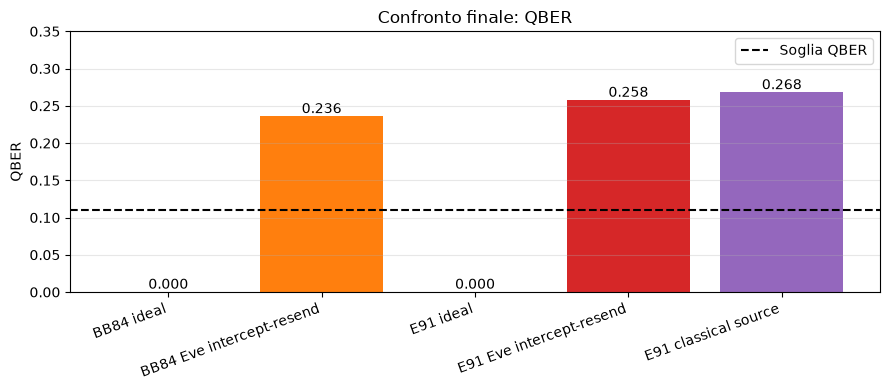

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_qber_comparison.png


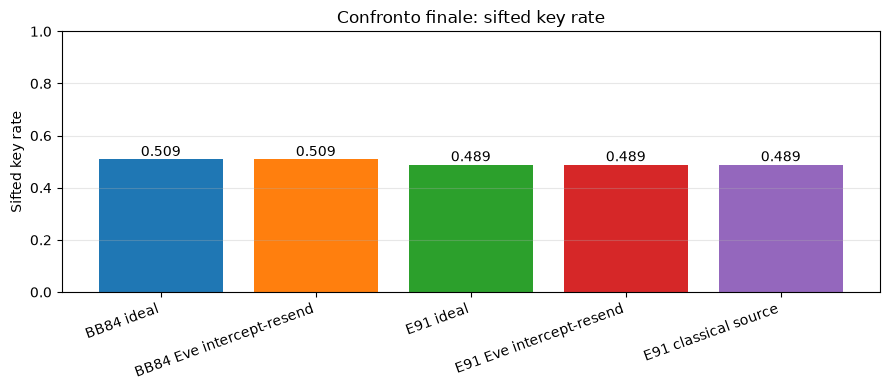

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_sifted_key_rate_comparison.png


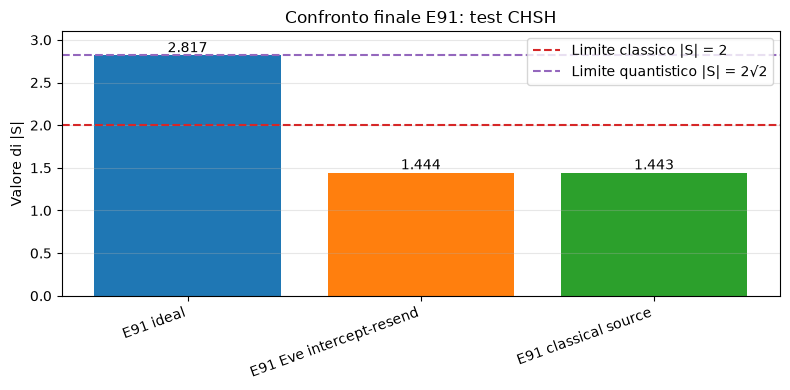

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_e91_chsh_comparison.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = final_qkd_df["scenario"]
values = final_qkd_df["qber"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
bars = ax.bar(labels, values, color=colors)
annotate_bars(ax, bars)
ax.axhline(QBER_THRESHOLD, linestyle="--", color="black", label="Soglia QBER")
ax.set_title("Confronto finale: QBER")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.35, values.max() + 0.05))
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
figure_path = figures_dir / "final_qber_comparison.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

fig, ax = plt.subplots(figsize=(9, 4))
values = final_qkd_df["sifted_key_rate"]
bars = ax.bar(labels, values, color=colors)
annotate_bars(ax, bars)
ax.set_title("Confronto finale: sifted key rate")
ax.set_ylabel("Sifted key rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
figure_path = figures_dir / "final_sifted_key_rate_comparison.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

fig, ax = plt.subplots(figsize=(8, 4))
labels = final_chsh_df["scenario"]
values = final_chsh_df["abs_S"]
colors = ["tab:blue", "tab:orange", "tab:green"]
bars = ax.bar(labels, values, color=colors)
annotate_bars(ax, bars)
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="tab:red", label="Limite classico |S| = 2")
ax.axhline(CHSH_TSIRELSON_BOUND, linestyle="--", color="tab:purple", label="Limite quantistico |S| = 2\u221a2")
ax.set_title("Confronto finale E91: test CHSH")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
figure_path = figures_dir / "final_e91_chsh_comparison.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## Grafici rumore rappresentativo

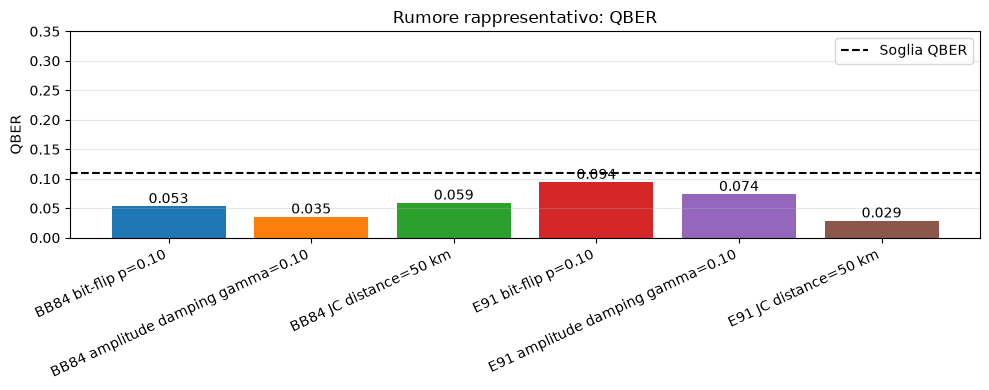

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_noise_qber_comparison.png


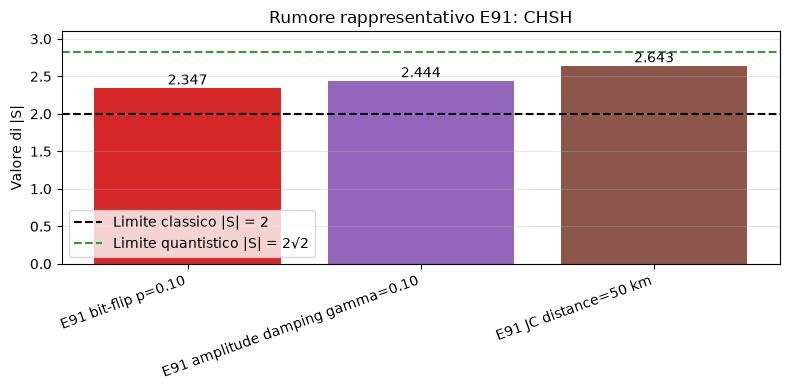

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_noise_chsh_comparison.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
labels = final_noise_df["scenario"]
values = final_noise_df["qber"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
bars = ax.bar(labels, values, color=colors)
annotate_bars(ax, bars)
ax.axhline(QBER_THRESHOLD, linestyle="--", color="black", label="Soglia QBER")
ax.set_title("Rumore rappresentativo: QBER")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.35, values.max() + 0.05))
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
figure_path = figures_dir / "final_noise_qber_comparison.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

e91_noise_chsh_df = final_noise_df[final_noise_df["protocol"] == "E91"]
fig, ax = plt.subplots(figsize=(8, 4))
labels = e91_noise_chsh_df["scenario"]
values = e91_noise_chsh_df["abs_S"]
colors = ["tab:red", "tab:purple", "tab:brown"]
bars = ax.bar(labels, values, color=colors)
annotate_bars(ax, bars)
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="black", label="Limite classico |S| = 2")
ax.axhline(CHSH_TSIRELSON_BOUND, linestyle="--", color="tab:green", label="Limite quantistico |S| = 2\u221a2")
ax.set_title("Rumore rappresentativo E91: CHSH")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
figure_path = figures_dir / "final_noise_chsh_comparison.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## Analisi finale del modello Jaynes-Cummings

Questa sezione mostra in modo compatto come il modello Jaynes-Cummings evolve al variare della distanza e del parametro `coupling_ratio`. Non ripete tutta l'analisi del notebook sul rumore: serve come analisi finale di sensibilità.

In [ ]:
JC_DISTANCES_KM = [0, 10, 25, 50, 75, 100]
JC_COUPLING_RATIOS = [0.05, 0.1, 0.2, 0.4]
ATTENUATION_DB_PER_KM = 0.21
FIBER_SPEED_KM_S = 203390

jc_sensitivity_rows = []

for i in range(len(JC_COUPLING_RATIOS)):
    coupling_ratio = JC_COUPLING_RATIOS[i]

    for j in range(len(JC_DISTANCES_KM)):
        distance_km = JC_DISTANCES_KM[j]
        current_seed = SEED + i * 100 + j

        damping_probability = compute_jc_damping_probability_from_distance(
            distance_km,
            attenuation_db_per_km=ATTENUATION_DB_PER_KM,
            coupling_ratio=coupling_ratio,
            fiber_speed_km_s=FIBER_SPEED_KM_S,
        )

        bb84_results = run_bb84_protocol_with_jc_amplitude_damping(
            N_ROUNDS,
            distance_km=distance_km,
            attenuation_db_per_km=ATTENUATION_DB_PER_KM,
            coupling_ratio=coupling_ratio,
            fiber_speed_km_s=FIBER_SPEED_KM_S,
            seed=current_seed,
        )
        bb84_metrics = compute_notebook_qkd_metrics(bb84_results)

        e91_results = run_e91_protocol_with_jc_amplitude_damping(
            N_ROUNDS,
            distance_km=distance_km,
            channel_mode=CHANNEL_MODE,
            attenuation_db_per_km=ATTENUATION_DB_PER_KM,
            coupling_ratio=coupling_ratio,
            fiber_speed_km_s=FIBER_SPEED_KM_S,
            seed=current_seed,
        )
        e91_metrics = compute_notebook_qkd_metrics(e91_results)

        e91_chsh = run_chsh_experiment_with_jc_amplitude_damping(
            distance_km=distance_km,
            channel_mode=CHANNEL_MODE,
            attenuation_db_per_km=ATTENUATION_DB_PER_KM,
            coupling_ratio=coupling_ratio,
            fiber_speed_km_s=FIBER_SPEED_KM_S,
            shots=SHOTS_CHSH,
            seed=current_seed,
        )

        jc_sensitivity_rows.append({
            "distance_km": distance_km,
            "coupling_ratio": coupling_ratio,
            "damping_probability": damping_probability,
            "bb84_qber": bb84_metrics["qber"],
            "bb84_sifted_key_rate": bb84_metrics["sifted_key_rate"],
            "bb84_accepted": bb84_metrics["accepted"],
            "e91_qber": e91_metrics["qber"],
            "e91_sifted_key_rate": e91_metrics["sifted_key_rate"],
            "e91_accepted": e91_metrics["accepted"],
            "e91_abs_S": abs(e91_chsh["S"]),
            "e91_violates_chsh": abs(e91_chsh["S"]) > CHSH_CLASSICAL_LIMIT,
            "e91_chsh_gap": e91_chsh["chsh_gap"],
            "e91_chsh_strength": e91_chsh["chsh_strength"],
            "seed": current_seed,
        })

jc_sensitivity_df = pd.DataFrame(jc_sensitivity_rows)
jc_sensitivity_path = tables_dir / "final_jc_sensitivity_distance_coupling.csv"
jc_sensitivity_df.to_csv(jc_sensitivity_path, index=False)

print(f"Tabella salvata in: {jc_sensitivity_path}")
jc_sensitivity_df.head(10)

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\final_jc_sensitivity_distance_coupling.csv


,distance_km,coupling_ratio,damping_probability,bb84_qber,bb84_sifted_key_rate,bb84_accepted,e91_qber,e91_sifted_key_rate,e91_accepted,e91_abs_S,e91_violates_chsh,e91_chsh_gap,e91_chsh_strength,seed
0,0,0.05,0.000000,0.000000,0.509,True,0.000000,0.489,True,2.830,True,0.830,1.001899,42
1,10,0.05,0.004998,0.001992,0.502,True,0.000000,0.509,True,2.780,True,0.780,0.941543,43
2,25,0.05,0.025139,0.015152,0.528,True,0.001992,0.502,True,2.826,True,0.826,0.997070,44
3,50,0.05,0.073199,0.032000,0.500,True,0.020833,0.528,True,2.769,True,0.769,0.928265,45
4,75,0.05,0.125776,0.054000,0.500,True,0.044000,0.500,True,2.641,True,0.641,0.773755,46
5,100,0.05,0.177413,0.059794,0.485,True,0.048000,0.500,True,2.542,True,0.542,0.654252,47
6,0,0.10,0.000000,0.000000,0.492,True,0.000000,0.515,True,2.819,True,0.819,0.988620,142
7,10,0.10,0.009979,0.002141,0.467,True,0.000000,0.492,True,2.804,True,0.804,0.970514,143
8,25,0.10,0.049821,0.020492,0.488,True,0.004283,0.467,True,2.794,True,0.794,0.958443,144
9,50,0.10,0.142236,0.056225,0.498,True,0.045082,0.488,True,2.593,True,0.593,0.715814,145


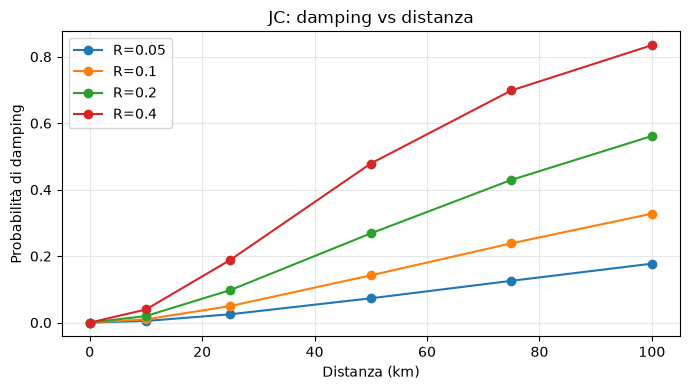

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_jc_damping_probability_sensitivity.png


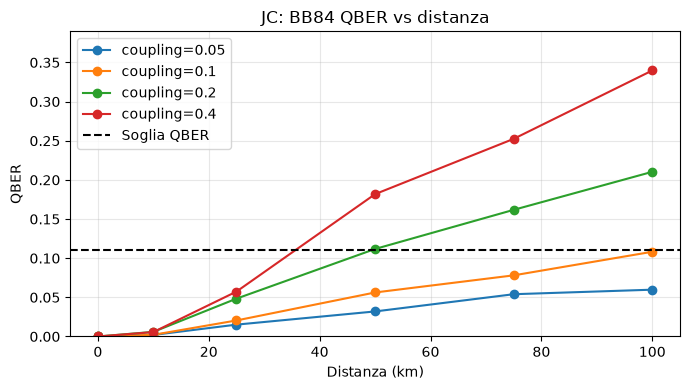

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_jc_bb84_qber_sensitivity.png


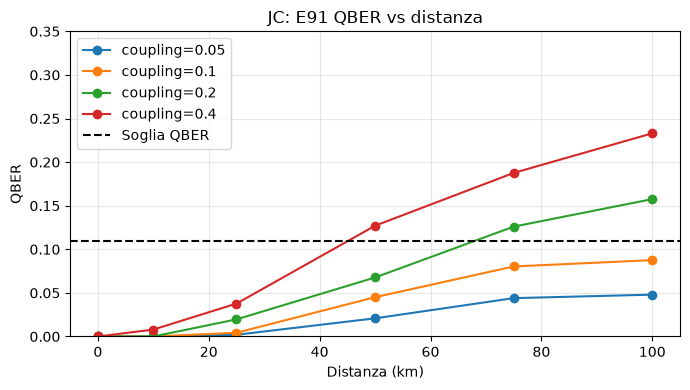

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_jc_e91_qber_sensitivity.png


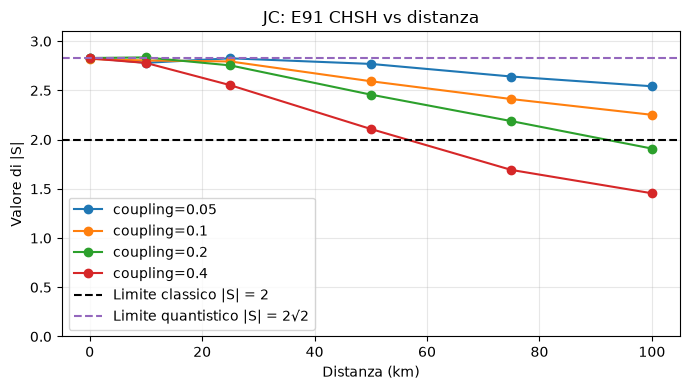

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_jc_e91_chsh_sensitivity.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for i in range(len(JC_COUPLING_RATIOS)):
    coupling_ratio = JC_COUPLING_RATIOS[i]
    subset = jc_sensitivity_df[jc_sensitivity_df["coupling_ratio"] == coupling_ratio]
    ax.plot(subset["distance_km"], subset["damping_probability"], marker="o", label=f"R={coupling_ratio}")
ax.set_title("JC: damping vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("Probabilità di damping")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "final_jc_damping_probability_sensitivity.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(len(JC_COUPLING_RATIOS)):
    coupling_ratio = JC_COUPLING_RATIOS[i]
    subset = jc_sensitivity_df[jc_sensitivity_df["coupling_ratio"] == coupling_ratio]
    ax.plot(subset["distance_km"], subset["bb84_qber"], marker="o", label=f"R={coupling_ratio}")
ax.axhline(QBER_THRESHOLD, linestyle="--", color="black", label="Soglia QBER")
ax.set_title("JC: BB84 QBER vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.35, jc_sensitivity_df["bb84_qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "final_jc_bb84_qber_sensitivity.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(len(JC_COUPLING_RATIOS)):
    coupling_ratio = JC_COUPLING_RATIOS[i]
    subset = jc_sensitivity_df[jc_sensitivity_df["coupling_ratio"] == coupling_ratio]
    ax.plot(subset["distance_km"], subset["e91_qber"], marker="o", label=f"R={coupling_ratio}")
ax.axhline(QBER_THRESHOLD, linestyle="--", color="black", label="Soglia QBER")
ax.set_title("JC: E91 QBER vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.35, jc_sensitivity_df["e91_qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "final_jc_e91_qber_sensitivity.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(len(JC_COUPLING_RATIOS)):
    coupling_ratio = JC_COUPLING_RATIOS[i]
    subset = jc_sensitivity_df[jc_sensitivity_df["coupling_ratio"] == coupling_ratio]
    ax.plot(subset["distance_km"], subset["e91_abs_S"], marker="o", label=f"R={coupling_ratio}")
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="black", label="Limite classico |S| = 2")
ax.axhline(CHSH_TSIRELSON_BOUND, linestyle="--", color="tab:purple", label="Limite quantistico |S| = 2\u221a2")
ax.set_title("JC: E91 CHSH vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "final_jc_e91_chsh_sensitivity.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## Rumore vs attacco: firma sperimentale su QBER e CHSH

Questa sezione confronta scenari ideali, scenari con attacco e scenari rumorosi usando le stesse metriche. L'obiettivo è mostrare che rumore e attacco non producono necessariamente la stessa firma sperimentale.

In [20]:
signature_rows = []

signature_rows.append({
    "protocol": "BB84",
    "scenario_type": "ideal",
    "scenario": "BB84 ideal",
    "qber": bb84_ideal_metrics["qber"],
    "sifted_key_rate": bb84_ideal_metrics["sifted_key_rate"],
    "accepted": bb84_ideal_metrics["accepted"],
    "abs_S": None,
    "violates_chsh": None,
    "chsh_gap": None,
    "chsh_strength": None,
})
signature_rows.append({
    "protocol": "BB84",
    "scenario_type": "attack",
    "scenario": "BB84 Eve intercept-resend",
    "qber": bb84_eve_metrics["qber"],
    "sifted_key_rate": bb84_eve_metrics["sifted_key_rate"],
    "accepted": bb84_eve_metrics["accepted"],
    "abs_S": None,
    "violates_chsh": None,
    "chsh_gap": None,
    "chsh_strength": None,
})

for scenario_name in ["BB84 bit-flip p=0.10", "BB84 amplitude damping gamma=0.10", "BB84 JC distance=50 km"]:
    row = final_noise_df[final_noise_df["scenario"] == scenario_name].iloc[0]
    signature_rows.append({
        "protocol": "BB84",
        "scenario_type": "noise",
        "scenario": row["scenario"],
        "qber": row["qber"],
        "sifted_key_rate": row["sifted_key_rate"],
        "accepted": row["accepted"],
        "abs_S": None,
        "violates_chsh": None,
        "chsh_gap": None,
        "chsh_strength": None,
    })

signature_rows.append({
    "protocol": "E91",
    "scenario_type": "ideal",
    "scenario": "E91 ideal",
    "qber": e91_ideal_metrics["qber"],
    "sifted_key_rate": e91_ideal_metrics["sifted_key_rate"],
    "accepted": e91_ideal_metrics["accepted"],
    "abs_S": abs(chsh_ideal["S"]),
    "violates_chsh": abs(chsh_ideal["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": chsh_ideal["chsh_gap"],
    "chsh_strength": chsh_ideal["chsh_strength"],
})
signature_rows.append({
    "protocol": "E91",
    "scenario_type": "attack",
    "scenario": "E91 Eve intercept-resend",
    "qber": e91_eve_metrics["qber"],
    "sifted_key_rate": e91_eve_metrics["sifted_key_rate"],
    "accepted": e91_eve_metrics["accepted"],
    "abs_S": abs(chsh_eve["S"]),
    "violates_chsh": abs(chsh_eve["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": chsh_eve["chsh_gap"],
    "chsh_strength": chsh_eve["chsh_strength"],
})
signature_rows.append({
    "protocol": "E91",
    "scenario_type": "classical",
    "scenario": "classical source",
    "qber": e91_classical_metrics["qber"],
    "sifted_key_rate": e91_classical_metrics["sifted_key_rate"],
    "accepted": e91_classical_metrics["accepted"],
    "abs_S": abs(chsh_classical["S"]),
    "violates_chsh": abs(chsh_classical["S"]) > CHSH_CLASSICAL_LIMIT,
    "chsh_gap": chsh_classical["chsh_gap"],
    "chsh_strength": chsh_classical["chsh_strength"],
})

for scenario_name in ["E91 bit-flip p=0.10", "E91 amplitude damping gamma=0.10", "E91 JC distance=50 km"]:
    row = final_noise_df[final_noise_df["scenario"] == scenario_name].iloc[0]
    signature_rows.append({
        "protocol": "E91",
        "scenario_type": "noise",
        "scenario": row["scenario"],
        "qber": row["qber"],
        "sifted_key_rate": row["sifted_key_rate"],
        "accepted": row["accepted"],
        "abs_S": row["abs_S"],
        "violates_chsh": row["violates_chsh"],
        "chsh_gap": row["chsh_gap"],
        "chsh_strength": row["chsh_strength"],
    })

signature_df = pd.DataFrame(signature_rows)
signature_path = tables_dir / "final_attack_vs_noise_signature.csv"
signature_df.to_csv(signature_path, index=False)

print(f"Tabella salvata in: {signature_path}")
signature_df


Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\final_attack_vs_noise_signature.csv


,protocol,scenario_type,scenario,qber,sifted_key_rate,accepted,abs_S,violates_chsh,chsh_gap,chsh_strength
0,BB84,ideal,BB84 ideal,0.000000,0.509,True,NaN,None,NaN,NaN
1,BB84,attack,BB84 Eve intercept-resend,0.235756,0.509,False,NaN,None,NaN,NaN
2,BB84,noise,BB84 bit-flip p=0.10,0.053045,0.509,True,NaN,None,NaN,NaN
3,BB84,noise,BB84 amplitude damping gamma=0.10,0.035363,0.509,True,NaN,None,NaN,NaN
4,BB84,noise,BB84 JC distance=50 km,0.058939,0.509,True,NaN,None,NaN,NaN
5,E91,ideal,E91 ideal,0.000000,0.489,True,2.817,True,0.817,0.986206
6,E91,attack,E91 Eve intercept-resend,0.257669,0.489,False,1.444,False,-0.556,-0.671151
7,E91,classical,classical source,0.267894,0.489,False,1.443,False,-0.557,-0.672358
8,E91,noise,E91 bit-flip p=0.10,0.094070,0.489,True,2.347,True,0.347,0.418866
9,E91,noise,E91 amplitude damping gamma=0.10,0.073620,0.489,True,2.444,True,0.444,0.535955


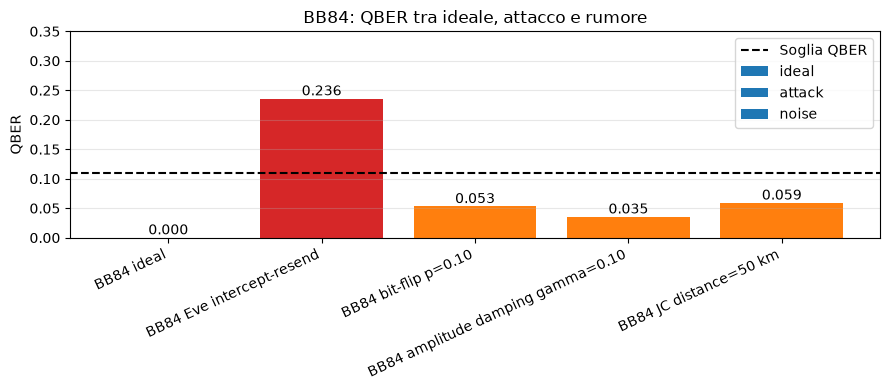

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_bb84_attack_vs_noise_qber.png


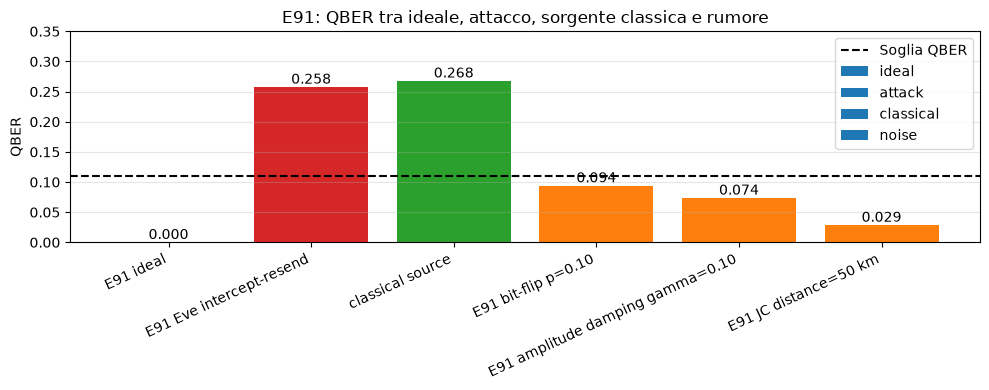

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_e91_attack_vs_noise_qber.png


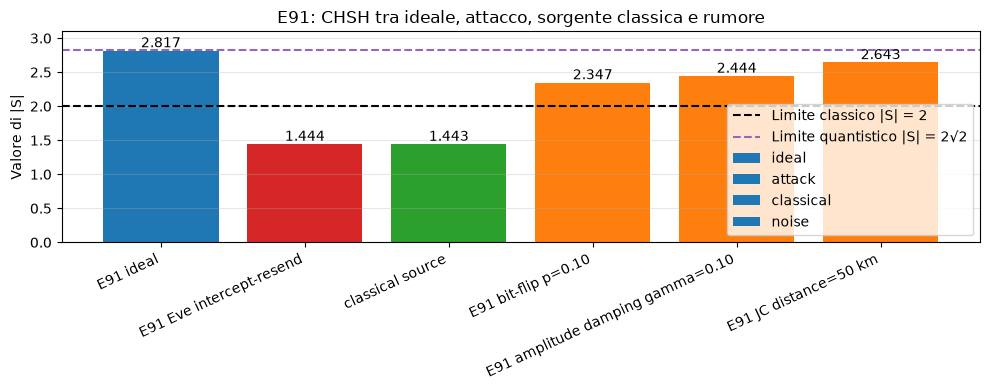

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_e91_attack_vs_noise_chsh.png


In [21]:
colors_by_type = {
    "ideal": "tab:blue",
    "attack": "tab:red",
    "classical": "tab:green",
    "noise": "tab:orange",
}

bb84_signature_df = signature_df[signature_df["protocol"] == "BB84"]
colors = []
for i in range(len(bb84_signature_df)):
    colors.append(colors_by_type[bb84_signature_df.iloc[i]["scenario_type"]])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(bb84_signature_df["scenario"], bb84_signature_df["qber"], color=colors)
annotate_bars(ax, bars)
for scenario_type in ["ideal", "attack", "noise"]:
    ax.bar([], [], color=colors_by_type[scenario_type], label=scenario_type)
ax.axhline(QBER_THRESHOLD, linestyle="--", color="black", label="Soglia QBER")
ax.set_title("BB84: QBER tra ideale, attacco e rumore")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.35, bb84_signature_df["qber"].max() + 0.05))
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
figure_path = figures_dir / "final_bb84_attack_vs_noise_qber.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

e91_signature_df = signature_df[signature_df["protocol"] == "E91"]
colors = []
for i in range(len(e91_signature_df)):
    colors.append(colors_by_type[e91_signature_df.iloc[i]["scenario_type"]])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(e91_signature_df["scenario"], e91_signature_df["qber"], color=colors)
annotate_bars(ax, bars)
for scenario_type in ["ideal", "attack", "classical", "noise"]:
    ax.bar([], [], color=colors_by_type[scenario_type], label=scenario_type)
ax.axhline(QBER_THRESHOLD, linestyle="--", color="black", label="Soglia QBER")
ax.set_title("E91: QBER tra ideale, attacco, sorgente classica e rumore")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.35, e91_signature_df["qber"].max() + 0.05))
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
figure_path = figures_dir / "final_e91_attack_vs_noise_qber.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(e91_signature_df["scenario"], e91_signature_df["abs_S"], color=colors)
annotate_bars(ax, bars)
for scenario_type in ["ideal", "attack", "classical", "noise"]:
    ax.bar([], [], color=colors_by_type[scenario_type], label=scenario_type)
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="black", label="Limite classico |S| = 2")
ax.axhline(CHSH_TSIRELSON_BOUND, linestyle="--", color="tab:purple", label="Limite quantistico |S| = 2√2")
ax.set_title("E91: CHSH tra ideale, attacco, sorgente classica e rumore")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
figure_path = figures_dir / "final_e91_attack_vs_noise_chsh.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")


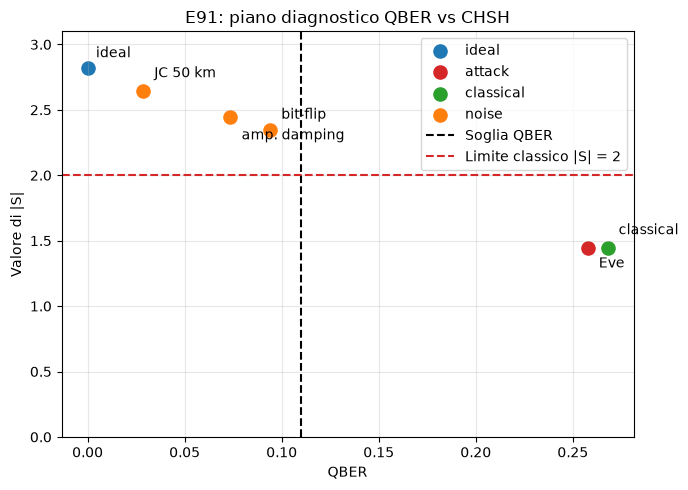

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\final_e91_qber_vs_chsh_diagnostic.png


In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

short_labels = ["ideal", "Eve", "classical", "bit-flip", "amp. damping", "JC 50 km"]
text_offsets = [(6, 8), (8, -14), (8, 10), (8, 8), (8, -16), (8, 10)]
used_labels = []

for i in range(len(e91_signature_df)):
    row = e91_signature_df.iloc[i]
    color = colors_by_type[row["scenario_type"]]
    label = row["scenario_type"]
    if label in used_labels:
        label = ""
    else:
        used_labels.append(label)

    ax.scatter(row["qber"], row["abs_S"], s=90, color=color, label=label)
    ax.annotate(
        short_labels[i],
        (row["qber"], row["abs_S"]),
        xytext=text_offsets[i],
        textcoords="offset points",
    )

ax.axvline(QBER_THRESHOLD, linestyle="--", color="black", label="Soglia QBER")
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="tab:red", label="Limite classico |S| = 2")
ax.set_title("E91: piano diagnostico QBER vs CHSH")
ax.set_xlabel("QBER")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "final_e91_qber_vs_chsh_diagnostic.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")


In BB84 il QBER è la metrica principale: per questo rumore e attacco possono apparire simili se producono valori di QBER comparabili.

In E91 la coppia QBER + CHSH è più informativa. Eve intercept-resend rappresenta un attacco attivo sul canale, mentre la sorgente classica rappresenta una sorgente senza vero entanglement: entrambi possono compromettere E91, ma per motivi diversi.

Il piano QBER-CHSH permette di separare scenari ideali, rumorosi, attaccati e classicamente correlati. La sorgente classica è particolarmente importante perché può produrre correlazioni nei bit, ma non una violazione CHSH robusta.


## Commento finale

BB84 ed E91 ideali producono QBER nullo nel modello simulato. L'attacco intercept-resend aumenta il QBER e rende la chiave non accettabile rispetto alla soglia didattica scelta.

E91 consente anche la verifica CHSH: la sorgente classica può produrre correlazioni, ma non una violazione CHSH robusta come quella dello stato entangled ideale. Rumore e distanza degradano QBER e, per E91, anche CHSH.

Il modello Jaynes-Cummings mostra il collegamento tra distanza, damping e perdita di qualità del canale. Nel complesso, BB84 è più diretto da simulare e interpretare tramite QBER, mentre E91 offre una metrica aggiuntiva legata alla natura quantistica delle correlazioni.